# Week 1: Customer Churn Analysis

## AnalystLab Africa Data Analytics Internship

### Business Analytics Case Study

**Prepared by:** Ajibola Ayobami

**Date:** August 2026

In [3]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

In [4]:
# Load the dataset

df = pd.read_csv("../Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Part 2: Dataset Inspection

In this section, we inspect the dataset by examining its dimensions, structure, data types, missing values, duplicate records, and summary statistics.

In [5]:
# Check the number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [6]:
# Display all column names

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [7]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [8]:
# Check for missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Check for duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Summary statistics for numerical columns

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
# Summary statistics including categorical columns

df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# Part 3: Data Cleaning

## Objective

The dataset was inspected for data quality issues. During the inspection, no duplicate rows or missing values were found using `isnull()`. However, the `TotalCharges` column was identified as having an incorrect data type (`object`) instead of a numeric type. In this section, we will clean and convert the column for proper analysis.

In [14]:
# Check the data type of TotalCharges

print(df["TotalCharges"].dtype)

str


In [15]:
# Count blank spaces in TotalCharges

blank_values = (df["TotalCharges"] == " ").sum()

print("Blank values:", blank_values)

Blank values: 11


In [16]:
# Convert TotalCharges from text to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [17]:
# Check missing values in TotalCharges after conversion
print(df["TotalCharges"].isnull().sum())

11


In [18]:
# Remove rows with missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

In [19]:
# Check the new dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (7032, 21)


In [20]:
# Check the data type after conversion
print(df["TotalCharges"].dtype)

float64


### Data Cleaning Summary

The `TotalCharges` column was initially stored as a text (`object`) data type due to the presence of 11 blank values. These blank values were converted to missing values (`NaN`) using `pd.to_numeric()` with `errors='coerce'`. The affected rows were then removed, resulting in a clean dataset with 7,032 records. The `TotalCharges` column is now stored as a numeric (`float64`) data type and is ready for analysis.

# Part 4: Business Data Analysis

In this section, the dataset is analyzed to answer key business questions about customer churn. Various charts and summary statistics are used to identify trends, patterns, and factors that influence customer retention.

## 1. Customer Gender Distribution

This chart shows the number of male and female customers in the dataset.

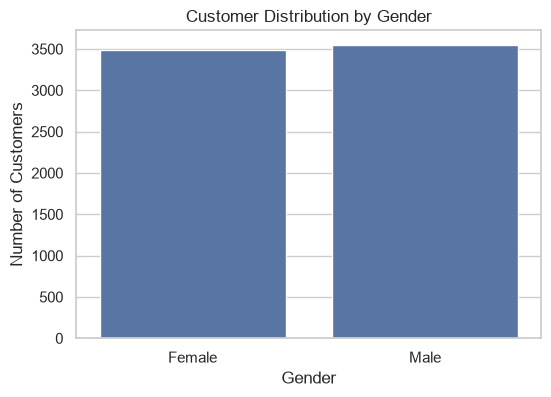

In [21]:
# Gender distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="gender")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The customer base is almost evenly divided between male and female customers. This indicates that the company serves both genders equally, suggesting that gender alone may not be a major factor influencing customer churn.

## 2. Customer Churn Distribution

This chart shows the number of customers who stayed and those who left the company.

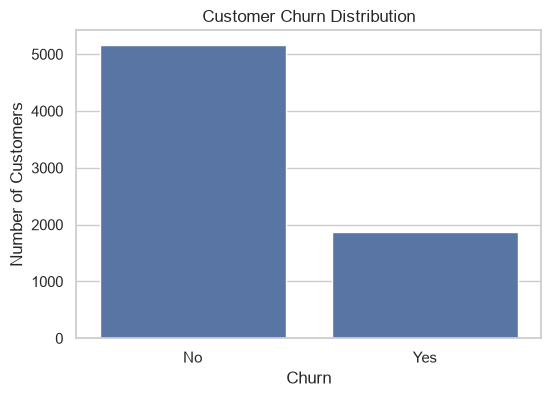

In [22]:
# Churn distribution

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

The majority of customers did not churn, while a smaller portion left the company. This indicates that customer retention is generally good, but understanding the characteristics of customers who churned is important for improving retention strategies.

## 3. Contract Type Distribution

This chart shows how customers are distributed across different contract types.

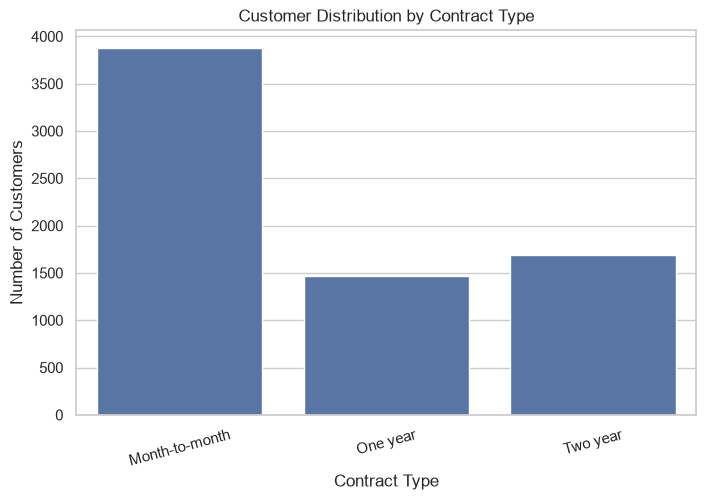

In [23]:
# Contract type distribution

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract")

plt.title("Customer Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Interpretation

This chart shows the popularity of each contract type among customers. The distribution helps identify whether most customers prefer month-to-month, one-year, or two-year contracts.

## 4. Churn by Gender

This chart compares customer churn between male and female customers.

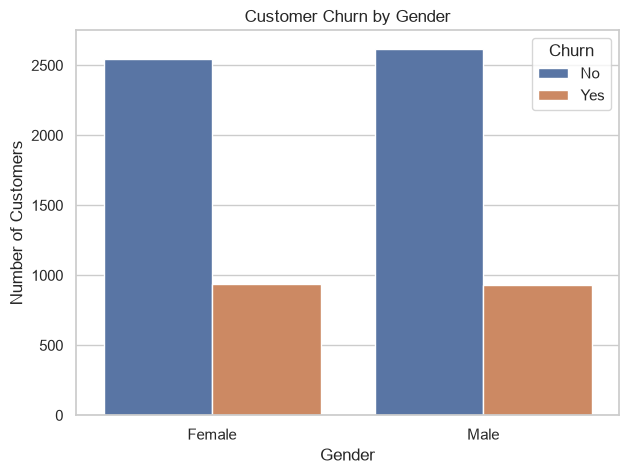

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="gender", hue="Churn")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Interpretation

This chart compares churn between male and female customers. If both genders show similar churn levels, gender is likely not a major driver of customer churn.

## 5. Churn by Contract Type

This chart compares customer churn across different contract types.

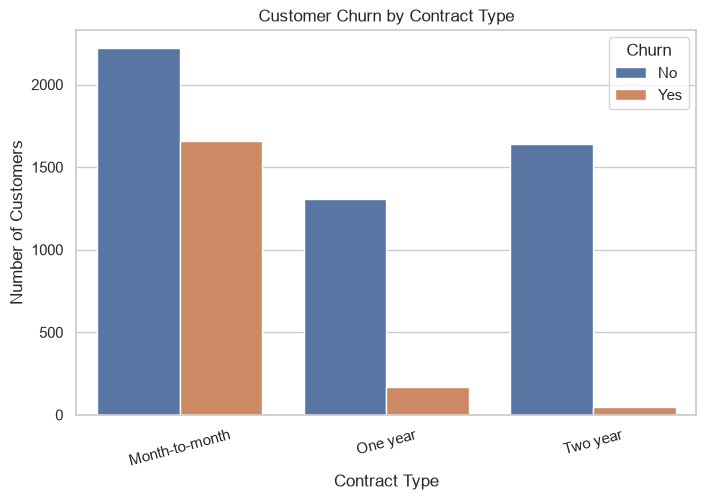

In [25]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

### Interpretation

Customers with month-to-month contracts generally experience higher churn than those with one-year or two-year contracts. Longer contracts appear to improve customer retention.

## 6. Overall Customer Churn

This pie chart shows the proportion of customers who stayed and those who churned.

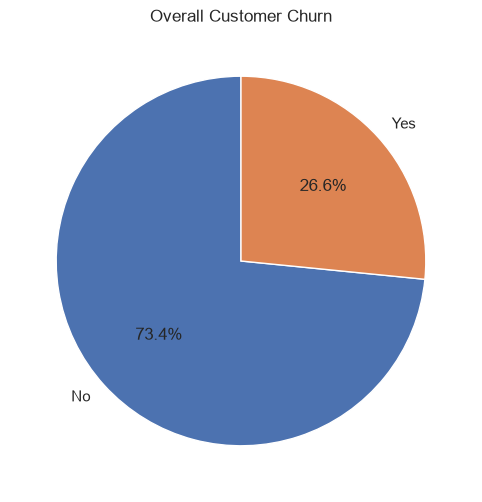

In [26]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Customer Churn")

plt.show()

### Interpretation

The majority of customers remained with the company, while a smaller percentage churned. Reducing this churn group can significantly improve long-term business performance.

## 7. Internet Service Distribution

This chart shows the percentage of customers using each internet service type.|

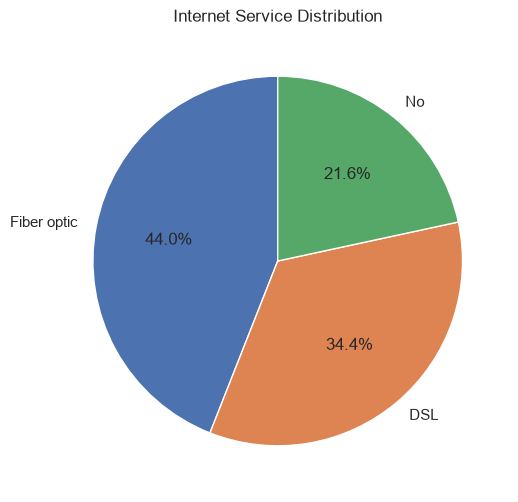

In [27]:
internet_counts = df["InternetService"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    internet_counts,
    labels=internet_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Internet Service Distribution")

plt.show()

### Interpretation

The chart illustrates how customers are distributed across internet service options. This helps identify the company's most commonly used service.

# Business Understanding

ABC Communications Ltd. aims to understand the factors influencing customer churn and develop strategies to improve customer retention. Customer churn occurs when customers discontinue using a company's services. High churn rates negatively impact revenue and increase customer acquisition costs.

The objective of this analysis is to identify customer characteristics associated with churn, evaluate service usage patterns, analyze contract and payment preferences, and provide actionable business recommendations to improve retention.

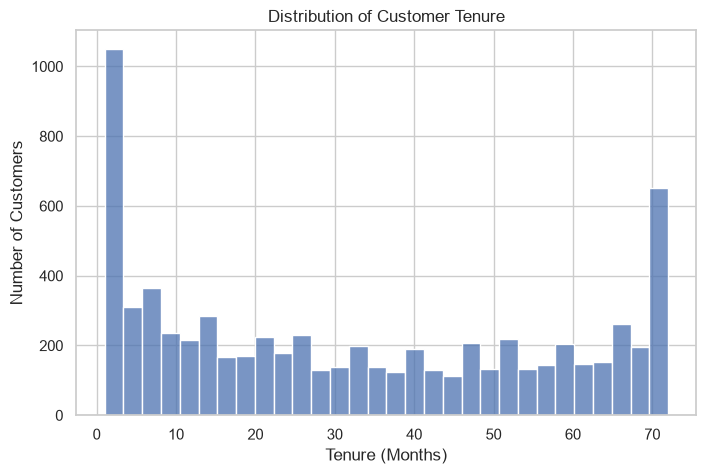

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["tenure"], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

Interpretation

Most customers have relatively short tenures, while fewer customers remain with the company for many years.

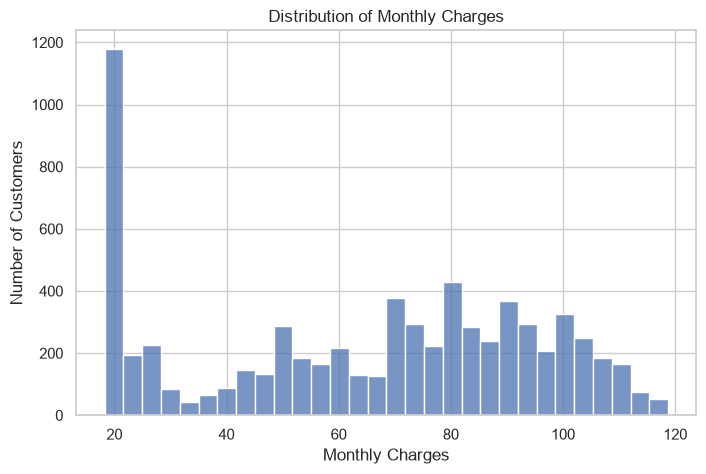

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

Interpretation:

Monthly charges vary considerably, with many customers concentrated within the lower and middle price ranges.

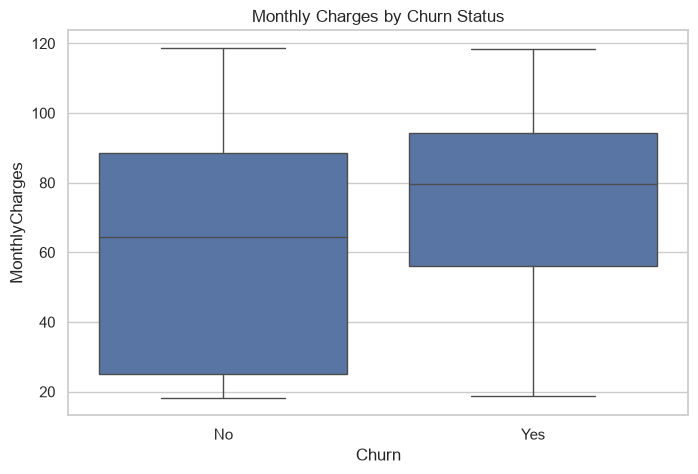

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges by Churn Status")

plt.show()

Interpretation:

Customers who churn tend to have higher monthly charges than customers who remain.

In [31]:
df["ChurnNumeric"] = df["Churn"].map({"No":0,"Yes":1})

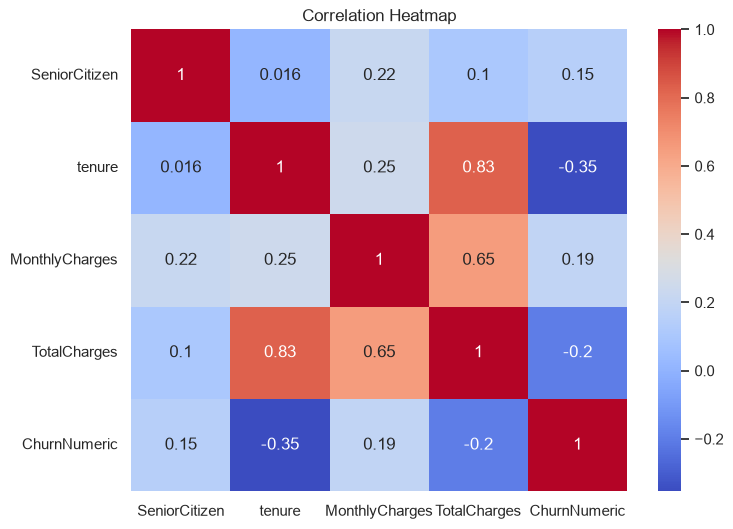

In [32]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

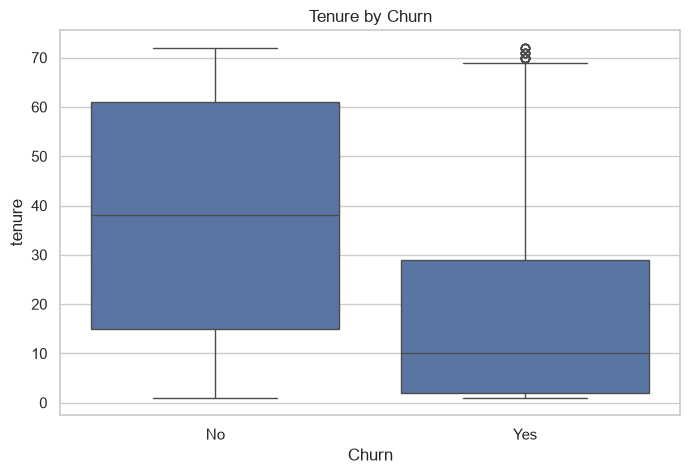

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="Churn",y="tenure")

plt.title("Tenure by Churn")

plt.show()

Interpretation:

Customers with shorter tenure are significantly more likely to churn than long-term customers.

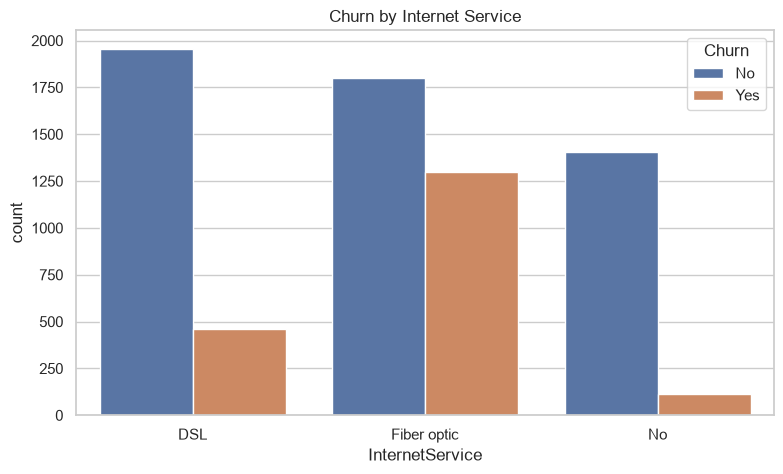

In [34]:
plt.figure(figsize=(9,5))

sns.countplot(data=df,x="InternetService",hue="Churn")

plt.title("Churn by Internet Service")

plt.show()

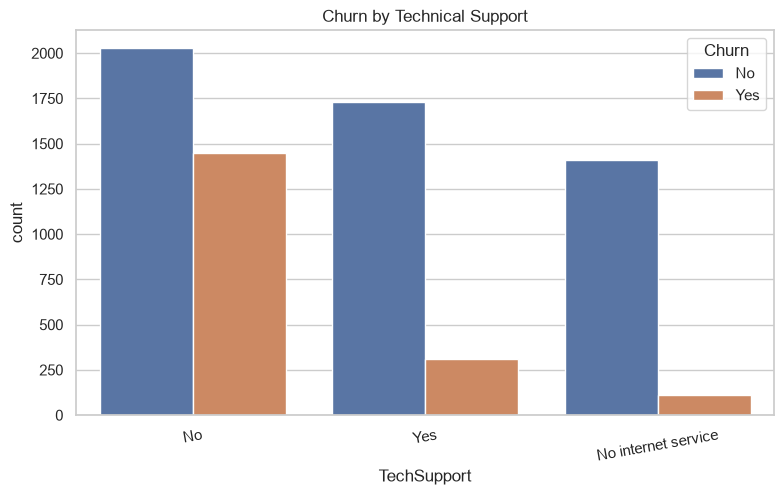

In [35]:
plt.figure(figsize=(9,5))

sns.countplot(data=df,x="TechSupport",hue="Churn")

plt.title("Churn by Technical Support")

plt.xticks(rotation=10)

plt.show()

Interpretation:

Customers without technical support generally exhibit higher churn.

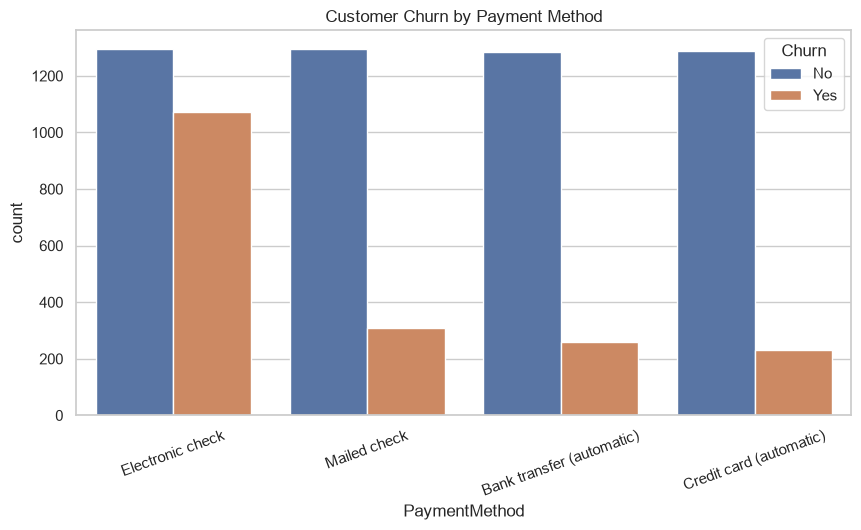

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(data=df,x="PaymentMethod",hue="Churn")

plt.xticks(rotation=20)

plt.title("Customer Churn by Payment Method")

plt.show()

Interpretation:

Electronic check users generally experience higher churn compared with customers using automatic payment methods.

# Business Insights

1. Month-to-month customers experience the highest churn.

2. Customers with short tenure are more likely to leave.

3. Customers without technical support have higher churn rates.

4. Higher monthly charges are associated with increased churn.

5. Long-term contracts improve customer retention.

# Business Risks

1. High churn among month-to-month customers reduces recurring revenue.

2. Customers paying higher monthly charges may become dissatisfied and leave.

3. Poor adoption of support services may negatively affect customer satisfaction.

# Business Opportunities

1. Encourage customers to switch to annual contracts.

2. Promote technical support and online security services.

3. Introduce loyalty rewards for long-term customers to keep them.

# Business Recommendations

1. Offer discounts for customers moving from month-to-month to yearly contracts.

2. Introduce early-retention campaigns targeting customers within their first six months.

3. Bundle technical support with internet packages.

4. Reward loyal customers through discounts and incentives.

5. Promote automatic payment methods to improve customer retention.

# Conclusion

The analysis identified several factors associated with customer churn, including contract type, tenure, monthly charges, technical support, and payment method. Customers on month-to-month contracts, those with shorter tenure, and those paying higher monthly charges are more likely to churn. By implementing targeted retention strategies, ABC Communications Ltd. can reduce customer churn, improve customer satisfaction, and increase long-term profitability.